# Infilling gaps in RADOLAN precipitation

This notebook trains a neural network to reconstruct missing values in gridded precipitation fields. Run the cells from top to bottom.

## 0. Imports

In [ ]:
# Utilities
import getpass
import os
import numpy as np
import xarray as xr
import mlflow
from utils import get_remap_matrix, conservative_remap, plot_sample
from tqdm import tqdm
from matplotlib import pyplot as plt

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

# PyTorch Lightning
import lightning.pytorch as pl
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import MLFlowLogger
from lightning.pytorch import Trainer

## 1. Objective

RADOLAN is a gridded, radar-derived precipitation dataset for Germany. Radar coverage and quality control can leave spatial gaps. We train a U-Net to estimate precipitation in these gaps from the surrounding spatial pattern.

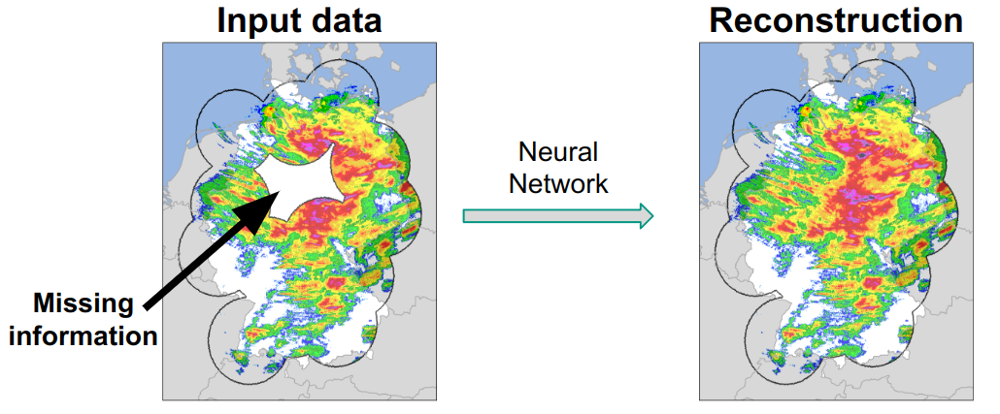

## 2. Data preparation

Missing-value patterns from the observations are used as masks. Available cells are marked `True`; cells to reconstruct are marked `False`.

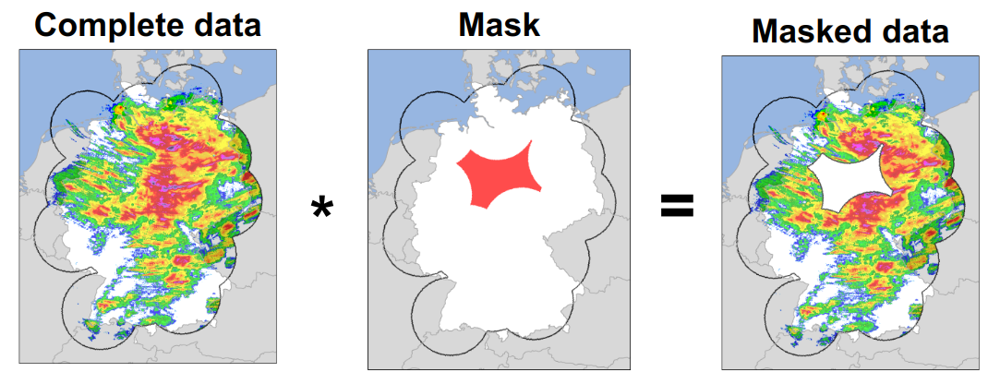

The original RADOLAN dataset has a high spatial resolution of 1100 × 900 grid cells. To reduce computation time in this exercise, we use a coarser version that has been conservatively remapped to 64 × 64 grid cells.

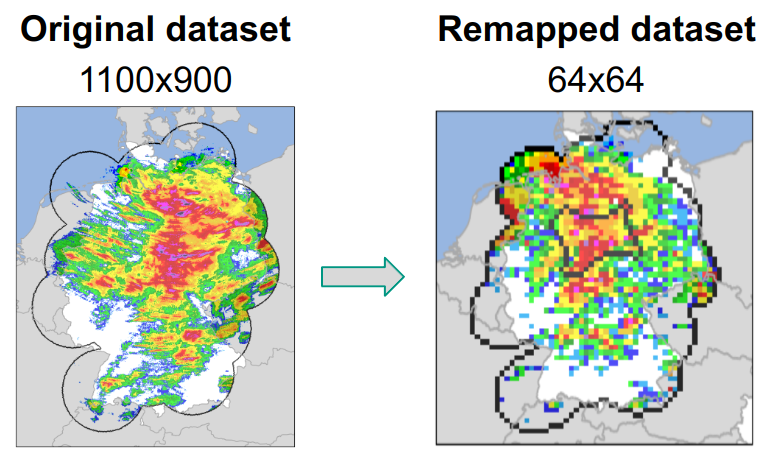

The next cell loads the observation and reference datasets, derives the missing-value mask, and prepares the conservative-remapping weights.

In [ ]:
path_obs = "/work/bk1444/hackathon_2026/challenge_2/data/radolan/radolan_incomplete_64x64.nc"
da_obs = xr.open_dataset(path_obs)["pr"]
# True marks an available observation; False marks a gap to reconstruct.
mask = ~torch.isnan(torch.tensor(da_obs.values).unsqueeze(1))
# The steady mask defines the spatial domain allowed for loss and plotting.
path_steady_mask = "/work/bk1444/hackathon_2026/challenge_2/data/radolan/steady_mask.nc"
if path_steady_mask is None:
    steady_mask = torch.ones((1, *da_obs.shape[-2:]), dtype=torch.bool)
else:
    steady_mask = torch.as_tensor(xr.open_dataset(path_steady_mask)["pr"].squeeze().values, dtype=torch.bool).unsqueeze(0)

files = open("data_files.txt").read().splitlines()
da_data = xr.open_mfdataset(files, combine="by_coords", chunks={"time": 128, "lat": -1, "lon": -1})["pr"]
remap_matrix, latlon = get_remap_matrix(da_data, da_obs)
da_data

We split the reference time series chronologically: the first 70% is used to train the model, the next 20% to monitor validation performance and the final 10% for an independent test. Keeping the periods in time order tests whether the model generalizes to later, unseen data.

In [ ]:
# Preserve time order so validation and test periods remain independent.
n_samples = da_data.sizes["time"]
train_end = int(0.7 * n_samples)
val_end = train_end + int(0.2 * n_samples)
da_train = da_data.isel(time=slice(None, train_end))
da_val   = da_data.isel(time=slice(train_end, val_end))
da_test  = da_data.isel(time=slice(val_end, None))

The network trains more reliably when precipitation values are standardized. We estimate the mean and standard deviation from a reproducible subset of the training period and process it in memory-efficient chunks.

In [ ]:
# Estimate normalization statistics from a reproducible training subset.
stats_percentage = 0.1
chunk_size = 16
rng = np.random.default_rng(42)
n_samples = max(1, round(stats_percentage * da_train.sizes["time"]))
indices = np.sort(rng.choice(da_train.sizes["time"], n_samples, replace=False))

# Accumulate moments in chunks without loading the full training set.
stats_mask = steady_mask[0].cpu().numpy()
vmin, vmax, count, total, total_squared = np.inf, -np.inf, 0, 0.0, 0.0
for start in tqdm(range(0, len(indices), chunk_size), desc="Computing stats"):
    batch = conservative_remap(da_train.isel(time=indices[start:start + chunk_size]).values, remap_matrix, da_obs.shape[-2:])
    batch = batch[:, stats_mask]
    vmin = min(vmin, batch.min())
    vmax = max(vmax, batch.max())
    count += batch.size
    total += batch.sum()
    total_squared += np.square(batch).sum()

stats = {"mean": total / count}
stats["std"] = np.sqrt(max(total_squared / count - stats["mean"]**2, 0.0))
print("* Min:", vmin)
print("* Max:", vmax)
print("* Mean:", stats["mean"])
print("* Std:", stats["std"])

`XRDataset` loads one time step on demand, remaps and standardizes it, and returns a PyTorch tensor together with its time index.

In [ ]:
class XRDataset(torch.utils.data.Dataset):
    def __init__(self, da, stats, target_shape, remap_matrix=None):
        self.da = da
        self.stats = stats
        self.remap_matrix = remap_matrix
        self.target_shape = target_shape

    def __len__(self):
        return self.da.sizes["time"]

    def __getitem__(self, i):
        values = self.da.isel(time=i).values
        values = conservative_remap(values, self.remap_matrix, self.target_shape)
        values = (values - self.stats["mean"]) / self.stats["std"]
        # In normalized space, zero represents the training mean.
        values = np.nan_to_num(values, nan=0.0)
        return torch.from_numpy(values).unsqueeze(0), i

Data loaders assemble time steps into batches. Only the training loader shuffles its samples between epochs.

In [ ]:
batch_size = 16
num_workers = 0
shape = da_obs.shape[-2:]

train_dataloader = DataLoader(XRDataset(da_train, stats, shape, remap_matrix), batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_dataloader = DataLoader(XRDataset(da_val, stats, shape, remap_matrix), batch_size=batch_size, num_workers=num_workers)
test_dataloader = DataLoader(XRDataset(da_test, stats, shape, remap_matrix), batch_size=batch_size, num_workers=num_workers)
print("Train: {}, Val: {}, Test: {}".format(len(train_dataloader.dataset), len(val_dataloader.dataset), len(test_dataloader.dataset)))

Before training, we inspect one field, its mask and the resulting network input.

Masked cells are shown as missing, while the target retains the corresponding reference values.

In [ ]:
i_plot = 0
gt_sample, mask_index = train_dataloader.dataset[i_plot]
mask_sample = mask[mask_index]
gt_sample = gt_sample.masked_fill(~steady_mask, torch.nan)
input_sample = gt_sample.masked_fill(~mask_sample, torch.nan)

fig = plot_sample([gt_sample, mask_sample, input_sample], ["Ground Truth", "Mask", "Input"], latlon)
plt.show()

With the data pipeline prepared, we can define the reconstruction model.

## 3. Model definition

A U-Net learns a mapping from a masked precipitation field to a complete field. Its encoder captures broad spatial structures, while its decoder restores the original grid resolution.
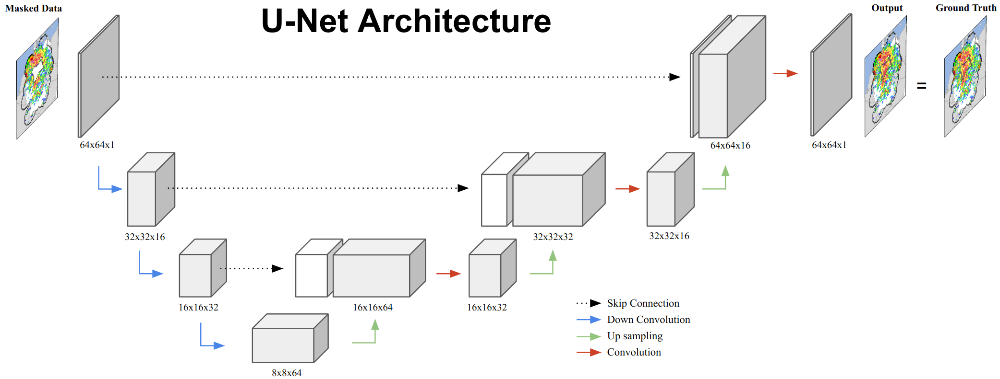

Each down-convolution halves the spatial resolution and increases the number of learned features. Each up-convolution enlarges the field and combines it with information retained from the encoder.
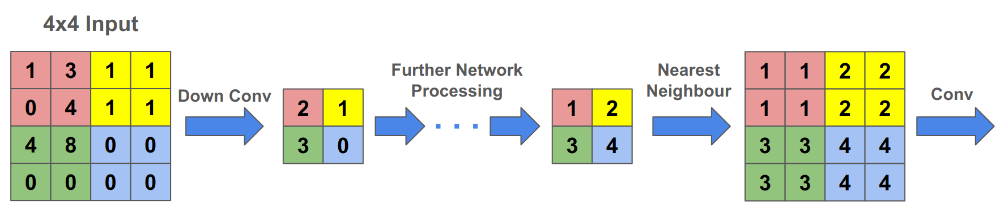

In [ ]:
# define the down convolution
class DownConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.down_conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=2, padding=1)
        self.batch_norm = nn.BatchNorm2d(out_channels)
        self.activation = nn.LeakyReLU()

    def forward(self, x):
        x = self.down_conv(x)
        x = self.batch_norm(x)
        return self.activation(x)


# define the up convolution
class UpConv(nn.Module):
    def __init__(self, in_channels, out_channels, batch_norm=True, activation=True):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.batch_norm = nn.BatchNorm2d(out_channels) if batch_norm else nn.Identity()
        self.activation = nn.LeakyReLU() if activation else nn.Identity()

    def forward(self, x, skip):
        x = F.interpolate(x, size=skip.shape[-2:], mode="nearest")
        # Restore fine spatial information from the matching encoder level.
        x = torch.cat([x, skip], dim=1)
        x = self.conv(x)
        x = self.batch_norm(x)
        return self.activation(x)

Skip connections pass fine-scale information directly from each encoder level to the corresponding decoder level. The final layer has no activation, so the model can predict the full range of normalized precipitation values.

In [ ]:
class UNet(nn.Module):
    def __init__(self, depth=3, max_channels=64, in_channels=1, out_channels=1):
        super().__init__()

        if depth < 1:
            raise ValueError("depth must be at least 1")

        self.depth = depth
        self.max_channels = max_channels

        encoder_channels = [max_channels // 2 ** (depth - level - 1) for level in range(depth)]
        if encoder_channels[0] < 1:
            raise ValueError("max_channels is too small for this depth")

        # The encoder reduces image size and increases channel count.
        self.encoder = nn.ModuleList()
        previous_channels = in_channels
        for channels in encoder_channels:
            self.encoder.append(DownConv(previous_channels, channels))
            previous_channels = channels

        # The decoder mirrors the encoder and restores the original size.
        self.decoder = nn.ModuleList()
        current_channels = encoder_channels[-1]
        for level in reversed(range(depth)):
            skip_channels = in_channels if level == 0 else encoder_channels[level - 1]
            next_channels = out_channels if level == 0 else skip_channels
            is_output_layer = level == 0
            self.decoder.append(UpConv(current_channels + skip_channels, next_channels, batch_norm=not is_output_layer, activation=not is_output_layer))
            current_channels = next_channels

    def forward(self, x):
        # Save each encoder result for the decoder skip connections.
        skip_connections = [x]
        for layer in self.encoder:
            x = layer(x)
            skip_connections.append(x)

        for level, layer in enumerate(self.decoder):
            skip = skip_connections[-level - 2]
            x = layer(x, skip)

        return x

The Lightning module organizes training and evaluation. It applies a missing-value mask, computes loss only inside the gaps, records diagnostics and converts predictions back to physical units. Adam updates the network parameters during training.

In [ ]:
class LightningUNet(pl.LightningModule):
    def __init__(self, model, loss, lr, stats, mask, steady_mask, shuffle_masks=True):
        super().__init__()
        self.model = model
        self.loss = loss
        self.lr = lr
        self.stats = stats
        # A buffer follows the model to the selected CPU or GPU device.
        self.register_buffer("mask", mask, persistent=False)
        self.register_buffer("steady_mask", steady_mask, persistent=False)
        self.shuffle_masks = shuffle_masks
        self.save_hyperparameters({
            "depth": model.depth,
            "max_channels": model.max_channels,
            "norm_mean": stats["mean"],
            "norm_std": stats["std"],
            "shuffle_masks": shuffle_masks
            })

    def on_fit_start(self):
        optimizer = self.trainer.optimizers[0]

        parameters = {
            "optimizer": optimizer.__class__.__name__,
            **{
                f"optimizer_{name}": value
                for name, value in optimizer.param_groups[0].items()
                if name != "params"
            },
        }

        self.logger.log_hyperparams(parameters)

    def forward(self, input_data):
        return self.model(input_data)

    def denormalize(self, x):
        return x * self.stats["std"] + self.stats["mean"]

    def apply_model(self, batch, shuffle_masks=False):
        gt_data, mask_indices = batch
        # Random masks expose each training field to different gap patterns.
        if shuffle_masks:
            mask_indices = torch.randint(low=0, high=len(self.mask), size=(len(gt_data),), device=gt_data.device)
        mask = self.mask[mask_indices]
        valid = self.steady_mask & mask
        missing = self.steady_mask & ~mask
        output = self(gt_data * valid)
        return output, gt_data, valid, missing

    def training_step(self, batch, batch_idx):
        output, gt_data, _, missing = self.apply_model(batch, self.shuffle_masks)
        # Train only where observations were hidden.
        loss = self.loss(gt_data[missing], output[missing])
        self.log("train_loss", loss, prog_bar=True, logger=True, on_step=True, on_epoch=True, sync_dist=True)
        return loss

    def validation_step(self, batch, batch_idx):
        output, gt_data, valid, missing = self.apply_model(batch, self.shuffle_masks)
        loss = self.loss(gt_data[missing], output[missing])
        self.log("val_loss", loss, prog_bar=True)

        if batch_idx == 0:
            fig = plot_sample([gt_data[0].masked_fill(~valid[0], torch.nan).detach().cpu(),
                               gt_data[0].masked_fill(~missing[0], torch.nan).detach().cpu(),
                               output[0].masked_fill(~missing[0], torch.nan).detach().cpu()],
                               ["Input", "Ground truth", "Predictions"], latlon)
            self.logger.experiment.log_figure(run_id=self.logger.run_id, figure=fig, artifact_file=f"epoch_{self.current_epoch:03d}.png")
            plt.close(fig)

    def predict_step(self, batch, batch_idx):
        output, gt_data, valid, missing = self.apply_model(batch)
        return self.denormalize(output), self.denormalize(gt_data), valid, missing

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)

## 4. Model training

We now choose the loss, learning rate and training duration. Validation data monitor performance on a later period that is not used to update the model.

The L1 loss is the mean absolute difference between predicted and reference precipitation inside masked cells. It is less sensitive to rare large errors than squared-error loss.

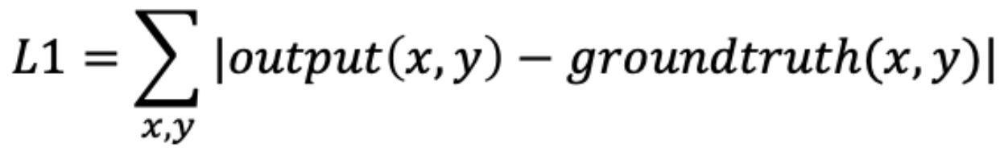

In [ ]:
loss = nn.L1Loss()
lr = 0.001
model = UNet(depth=3, max_channels=64)
pl_model = LightningUNet(model, loss, lr, stats, mask, steady_mask, shuffle_masks=True)
model

A checkpoint stores the epoch with the lowest validation loss. MLflow records the configuration, loss history and example reconstructions so that runs can be compared.

In [ ]:
checkpoint_callback = ModelCheckpoint(dirpath="checkpoints",
                                        monitor="val_loss",
                                        mode="min",
                                        save_top_k=1,
                                        filename="best-{epoch:02d}")

run_name = "name_of_your_run"
username = getpass.getuser()
os.environ["MLFLOW_TRACKING_USERNAME"] = username
os.environ["MLFLOW_TRACKING_PASSWORD"] = getpass.getpass("MLflow password: ")
mlflow.set_workspace("bk1444")

The trainer runs optimization on the GPU and evaluates the validation period after each epoch.

In [ ]:
logger = MLFlowLogger(tracking_uri="https://mlflow.dkrz.de", experiment_name="EXPECT_hackathon_C2", run_name=run_name, log_model=False, synchronous=False)

trainer_params = {
    "accelerator": "gpu",
    "devices": 1,
    "max_epochs": 20,
    "check_val_every_n_epoch": 1,
    "log_every_n_steps": 100,
    "num_sanity_val_steps": 0,
}

trainer = Trainer(**trainer_params,
                  callbacks=[checkpoint_callback],
                  logger=logger,
                  enable_progress_bar=True)

logger.log_hyperparams({"loss": loss.__class__.__name__, "batch_size": batch_size,
                        **{f"trainer_{name}": value for name, value in trainer_params.items()}})

with mlflow.start_run(run_id=logger.run_id, log_system_metrics=True):
    trainer.fit(model=pl_model, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)

One epoch is one pass through the training data. Training and validation losses should generally decrease before levelling off; a growing separation can indicate overfitting.

## 5. Evaluation and infilling

The best checkpoint is evaluated on the final, unseen test period. MAE and RMSE measure error magnitude inside the gaps; spatial correlation measures similarity of the predicted and reference patterns. We then apply the model to the observations and combine predicted gap values with the available measurements.

In [ ]:
batches = trainer.predict(model=pl_model, dataloaders=test_dataloader, ckpt_path=checkpoint_callback.best_model_path)
predictions, targets, valid, missing = [torch.cat(x).cpu().numpy() for x in zip(*batches)]

# Retain scores only inside the artificial gaps.
inputs = targets.copy()
inputs[~valid] = np.nan
targets[~missing] = np.nan
predictions[~missing] = np.nan
diff = predictions - targets

mae = np.nanmean(np.abs(diff))
rmse = np.sqrt(np.nanmean(diff**2))

from scipy.stats import pearsonr
corr = []
for prediction, target, missing_ in tqdm(zip(predictions, targets, missing)):
    corr.append(pearsonr(prediction[missing_], target[missing_]).statistic)
spatial_corr = np.nanmean(corr)

print(f"Best model: {checkpoint_callback.best_model_path}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"Spatial correlation: {spatial_corr:.4f}")

These maps compare masked inputs, reference fields and reconstructions for selected test times.

In [ ]:
i_plot = [0, 1, 2]
fig = plot_sample([inputs[i_plot], targets[i_plot], predictions[i_plot]], ["Input", "Ground truth", "Predictions"], latlon)
plt.show()

We now create a loader for the observations, predict their missing values and form a composite. The composite retains measured values and inserts model estimates only in gaps.

In [ ]:

data_obs = XRDataset(da_obs, stats, da_obs.shape[-2:])
obs_dataloader = DataLoader(data_obs, batch_size=batch_size, num_workers=num_workers)

batches = trainer.predict(model=pl_model, dataloaders=obs_dataloader, ckpt_path=checkpoint_callback.best_model_path)
predictions, targets, valid, missing = [torch.cat(x).cpu().numpy() for x in zip(*batches)]
# Keep observations where available and fill only their gaps.
composite = predictions.copy()
composite[valid] = targets[valid]
targets[~valid] = np.nan
predictions[:, :, ~steady_mask[0]] = np.nan
composite[:, :, ~steady_mask[0]] = np.nan

The final comparison shows the original observation, the full model prediction and the merged field.

In [ ]:
i_plot = [0, 1, 2]
fig = plot_sample([targets[i_plot], predictions[i_plot], composite[i_plot]], ["Input", "Predictions", "Composite"], latlon)
plt.show()

## 6. Full-resolution RADOLAN example

A related CRAI model was trained at DKRZ on RADOLAN fields at their original 1100 × 900 resolution. The animations compare the masked input, reconstruction and reference field.

| Input | Reconstruction | Reference |
|:---:|:---:|:---:|
| 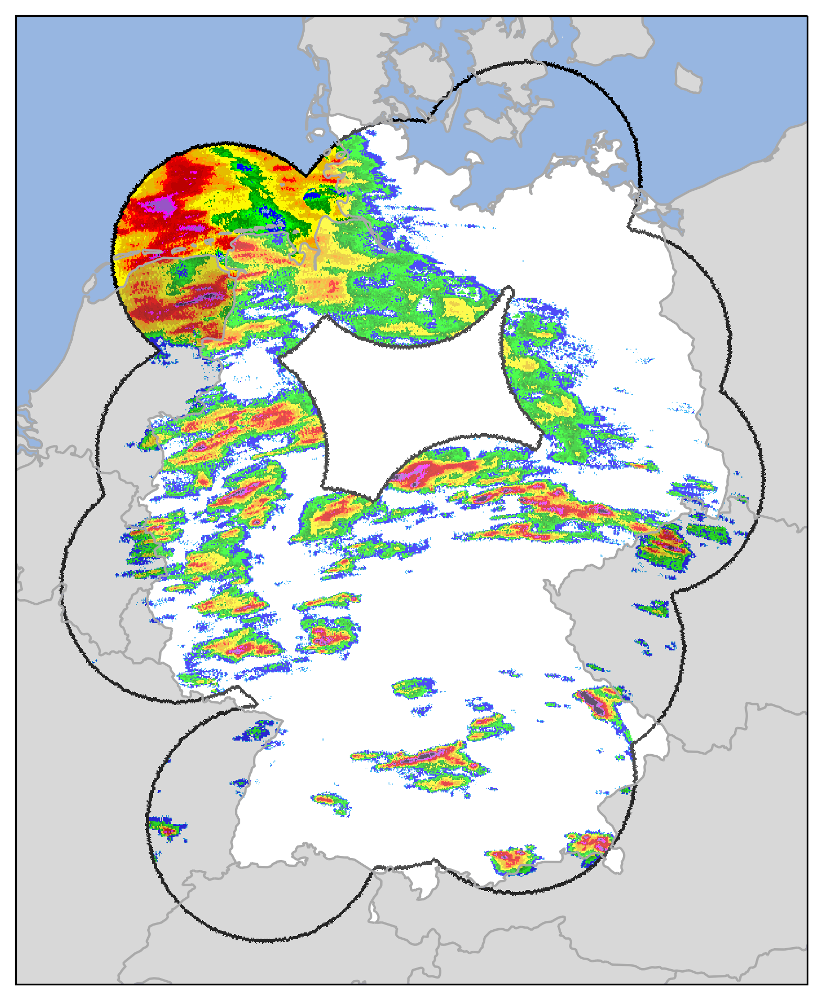 | 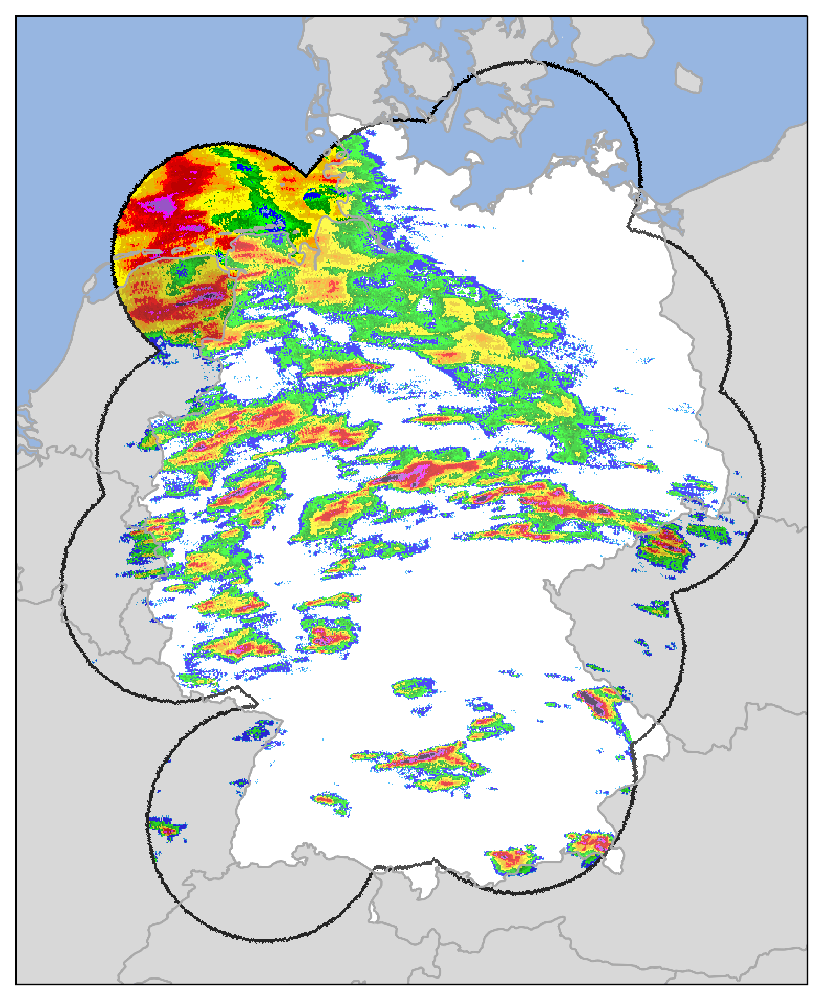 | 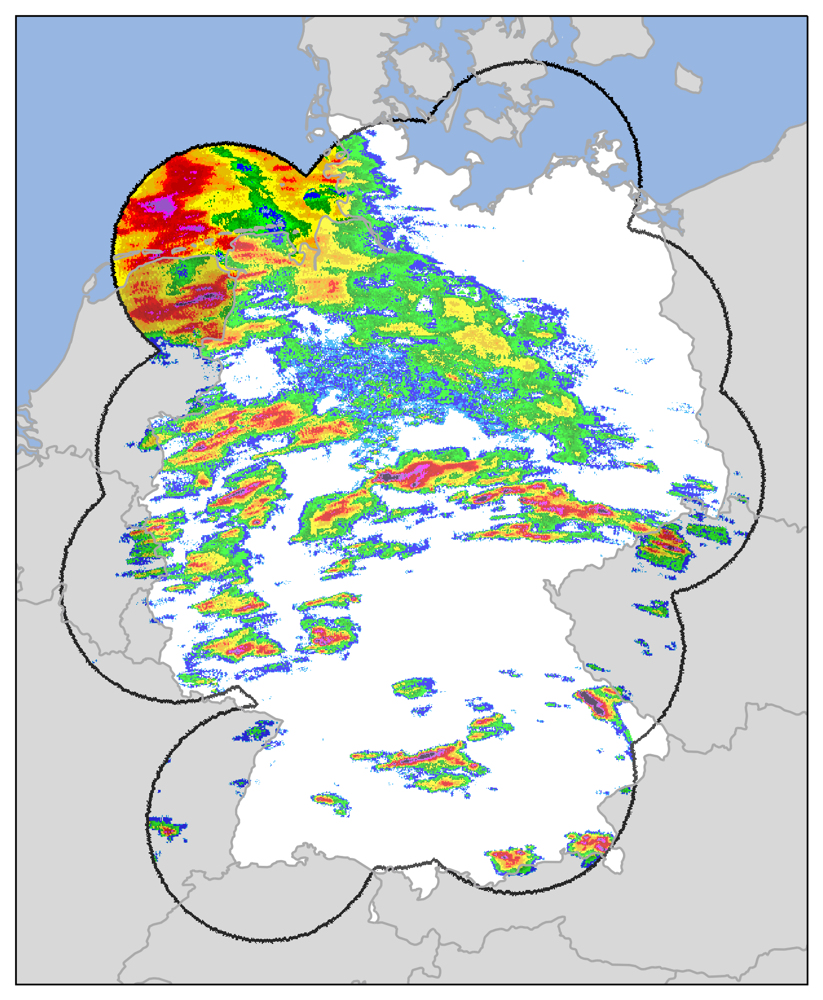 |